# Toy 1D Regression: Paper Plots for SVD-SGD

## 1. Setup & Data Loading

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path
import warnings
import re
warnings.filterwarnings('ignore')
from matplotlib.lines import Line2D
import seaborn as sns

# Paper-quality plot settings
plt.rcParams.update({
    'font.size': 16,
    'axes.labelsize': 16,
    'axes.titlesize': 16,
    'legend.fontsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'figure.figsize': (8, 8),
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'lines.linewidth': 2,
    'axes.grid': False,
    'grid.alpha': 0.3,
    'font.family': 'arial',
    'legend.frameon': False
})

# Output directory for plots
PLOT_DIR = Path('plots/toy_1d')
PLOT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Plots will be saved to: {PLOT_DIR.absolute()}")

Plots will be saved to: /Users/sambt/iaifi/sv3/claude_experiments/plots/toy_1d


In [2]:
# Load all experiment results and combine into single DataFrame
RESULTS_DIR = Path('../experiment_results/toy_1d_scan/')

all_dfs = []
file_pattern = '*.pkl'

for filepath in sorted(RESULTS_DIR.glob(file_pattern)):
    with open(filepath, 'rb') as f:
        df_temp = pickle.load(f)
    all_dfs.append(df_temp)
    print(f"Loaded {filepath.name}: {len(df_temp)} rows")

df = pd.concat(all_dfs, ignore_index=True)
print(f"\nTotal: {len(df)} experiment runs")
print(f"\nColumns: {df.columns.tolist()}")

Loaded toy_1d_scan_results_bs128_df.pkl: 24 rows
Loaded toy_1d_scan_results_bs32_df.pkl: 24 rows
Loaded toy_1d_scan_results_bs64_df.pkl: 24 rows

Total: 72 experiment runs

Columns: ['batch_size', 'k_fraction', 'k', 'lr', 'losses', 'svd_info', 'optimizer']


In [5]:
# Separate SVD and baseline results
df_svd = df[df['optimizer'] == 'SVD'].copy()
df_baseline = df[df['optimizer'] != 'SVD'].copy()

# Extract unique hyperparameters
batch_sizes = sorted(df['batch_size'].unique())
k_fractions = sorted(df_svd['k_fraction'].dropna().unique())
svd_lrs = sorted(df_svd['lr'].unique())
baseline_lrs = sorted(df_baseline['lr'].unique())
baseline_optimizers = df_baseline['optimizer'].unique().tolist()
baseline_optimizers.remove("AdamW")

print("SVD Hyperparameters:")
print(f"  k_fractions: {k_fractions}")
print(f"  Learning rates: {svd_lrs}")
print(f"\nBaseline Hyperparameters:")
print(f"  Optimizers: {baseline_optimizers}")
print(f"  Learning rates: {baseline_lrs}")

SVD Hyperparameters:
  k_fractions: [0.25, 0.5, 0.75, 1.0]
  Learning rates: [0.1, 0.5, 1.0]

Baseline Hyperparameters:
  Optimizers: ['Adam', 'SGD', 'RMSprop']
  Learning rates: [0.0001, 0.001, 0.01]


In [6]:
# Helper functions for extracting data
def get_final_loss(row, loss_type='val'):
    """Get final epoch loss."""
    return row['losses'][loss_type][-1]

def get_loss_curve(row, loss_type='val'):
    """Get per-epoch loss curve."""
    return np.array(row['losses'][loss_type])

def get_batch_losses(row, loss_type='train_batch'):
    """Get per-batch loss curve."""
    return np.array(row['losses'][loss_type])

def get_svd_info(row):
    """Get SVD singular values and counts."""
    if row['svd_info'] is None or pd.isna(row['svd_info']):
        return None, None
    return row['svd_info']['svs'], row['svd_info']['num_nonzero_svs']

def sliding_average(data, window=10):
    """Compute sliding average for smoothing."""
    return np.convolve(data, np.ones(window)/window, mode='valid')

# Add final validation loss column for easier analysis
df['final_val_loss'] = df.apply(lambda r: get_final_loss(r, 'val'), axis=1)
df['final_train_loss'] = df.apply(lambda r: get_final_loss(r, 'train'), axis=1)

df_svd = df[df['optimizer'] == 'SVD'].copy()
df_baseline = df[df['optimizer'] != 'SVD'].copy()

print("Added final_val_loss and final_train_loss columns")

Added final_val_loss and final_train_loss columns


## 2. Optimizer Comparison

Compare SVD optimizer performance against standard optimizers (Adam, AdamW, SGD, RMSprop).

### 2.1 Best Performance Comparison

For each optimizer, find the best hyperparameters and compare final validation loss.

In [40]:
# Find best run for each optimizer type
best_runs = []

# Best SVD
best_svd = df_svd.loc[df_svd['final_val_loss'].idxmin()]
best_runs.append({
    'optimizer': 'Sven',
    'final_val_loss': best_svd['final_val_loss'],
    'lr': best_svd['lr'],
    'batch_size': best_svd['batch_size'],
    'k': best_svd['k'],
    'k_fraction': best_svd['k_fraction']
})

# Best for each baseline optimizer
for opt in baseline_optimizers:
    opt_df = df_baseline[df_baseline['optimizer'] == opt]
    best = opt_df.loc[opt_df['final_val_loss'].idxmin()]
    best_runs.append({
        'optimizer': opt,
        'final_val_loss': best['final_val_loss'],
        'lr': best['lr'],
        'batch_size': best['batch_size'],
        'k': None,
        'k_fraction': None
    })

best_df = pd.DataFrame(best_runs)
print("Best performance for each optimizer:")
print(best_df.to_string(index=False))

Best performance for each optimizer:
optimizer  final_val_loss    lr  batch_size    k  k_fraction
     Sven    1.976659e-07 0.500          32 16.0         0.5
     Adam    1.060904e-05 0.001          32  NaN         NaN
      SGD    6.266532e-03 0.010          32  NaN         NaN
  RMSprop    1.146366e-05 0.001          32  NaN         NaN


### summary of best runs

In [41]:
# Plot: Best final validation loss by optimizer
fig, ax = plt.subplots(figsize=(7, 4))

colors = ['C0', 'C1', 'C2', 'C3', 'C4']
x = np.arange(len(best_df))
bars = ax.bar(x, best_df['final_val_loss'], color=colors)

ax.set_xticks(x)
ax.set_xticklabels(best_df['optimizer'])
ax.set_ylabel('Final Validation Loss')
ax.set_title('Best Final Validation Loss by Optimizer')
ax.set_yscale('log')

# Add value labels
for bar, val in zip(bars, best_df['final_val_loss']):
    ax.text(bar.get_x() + bar.get_width()/2, val, f'{val:.2e}', 
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(PLOT_DIR / 'best_optimizer_comparison.pdf')
plt.savefig(PLOT_DIR / 'best_optimizer_comparison.png')
plt.close()

In [42]:
# Plot: Best final validation loss vs batch size for each optimizer
fig, ax = plt.subplots(figsize=(8, 8))

# SVD: find best config at each batch size
svd_best_per_bs = []
for bs in batch_sizes:
    bs_data = df_svd[df_svd['batch_size'] == bs]
    best_idx = bs_data['final_val_loss'].idxmin()
    best_row = bs_data.loc[best_idx]
    svd_best_per_bs.append({
        'batch_size': bs,
        'final_val_loss': best_row['final_val_loss'],
        'lr': best_row['lr'],
        'k': int(best_row['k']),
        'k_fraction': best_row['k_fraction']
    })

svd_best_df = pd.DataFrame(svd_best_per_bs)
# Get the overall best config for legend
overall_best_svd = svd_best_df.loc[svd_best_df['final_val_loss'].idxmin()]
ax.plot(svd_best_df['batch_size'], svd_best_df['final_val_loss'], 'o-', 
        color='C0', linewidth=2, markersize=8,
        label=f"Sven (best: lr={overall_best_svd['lr']}, k={int(overall_best_svd['k'])})")

# Baseline optimizers: find best config at each batch size
for i, opt in enumerate(baseline_optimizers):
    opt_best_per_bs = []
    for bs in batch_sizes:
        bs_data = df_baseline[(df_baseline['batch_size'] == bs) & (df_baseline['optimizer'] == opt)]
        if len(bs_data) > 0:
            best_idx = bs_data['final_val_loss'].idxmin()
            best_row = bs_data.loc[best_idx]
            opt_best_per_bs.append({
                'batch_size': bs,
                'final_val_loss': best_row['final_val_loss'],
                'lr': best_row['lr']
            })
    
    opt_best_df = pd.DataFrame(opt_best_per_bs)
    # Get the overall best config for legend
    overall_best = opt_best_df.loc[opt_best_df['final_val_loss'].idxmin()]
    ax.plot(opt_best_df['batch_size'], opt_best_df['final_val_loss'], 's-',
            color=f'C{i+1}', linewidth=1.5, markersize=7,
            label=f"{opt} (best: lr={overall_best['lr']:.0e})")

ax.set_xlabel('Batch Size')
ax.set_ylabel('Best Validation Loss')
ax.set_xscale('log', base=2)
ax.set_yscale('log')
ax.set_xticks(batch_sizes)
ax.set_xticklabels(batch_sizes)
ax.legend(loc=(0.55,0.6))

plt.tight_layout()
plt.savefig(PLOT_DIR / 'best_loss_vs_batchsize.pdf')
#plt.savefig(PLOT_DIR / 'best_loss_vs_batchsize.png')
plt.close()

### 2.2 Training Curves: Best Configurations

In [55]:
# Plot training loss curves for best configuration of each optimizer
fig, ax = plt.subplots(figsize=(8, 8))

# Get best SVD run data
best_svd_idx = df_svd['final_val_loss'].idxmin()
best_svd_row = df.loc[best_svd_idx]

epochs = np.arange(20)

ax.plot(epochs, get_loss_curve(best_svd_row, 'train'), 'C0-', 
        label=f"Sven (lr={best_svd_row['lr']}, k={int(best_svd_row['k'])}, bs={int(best_svd_row['batch_size'])})")

for i, opt in enumerate(baseline_optimizers):
    opt_df = df_baseline[df_baseline['optimizer'] == opt]
    best_idx = opt_df['final_val_loss'].idxmin()
    best_row = df.loc[best_idx]
    ax.plot(epochs, get_loss_curve(best_row, 'train'), f'C{i+1}-',
            label=f"{opt} (lr={best_row['lr']:.0e}, bs={int(best_row['batch_size'])})")

ax.set_xlabel('Epoch')
ax.set_ylabel('Training Loss')
#ax.set_title('Training Loss (Best Configurations)')
ax.set_yscale('log')
plt.ylim([None,10])
ax.legend(loc='upper right',ncol=2)
ax.set_title("1D Regression")

plt.tight_layout()
plt.savefig(PLOT_DIR / 'training_loss_best.pdf')
#plt.savefig(PLOT_DIR / 'training_loss_best.png')
plt.close()

In [56]:
# Plot validation loss curves for best configuration of each optimizer
fig, ax = plt.subplots(figsize=(8, 8))

# Get best SVD run data
best_svd_idx = df_svd['final_val_loss'].idxmin()
best_svd_row = df.loc[best_svd_idx]

epochs = np.arange(21)

ax.plot(epochs, get_loss_curve(best_svd_row, 'val'), 'C0-',
        label=f"Sven (lr={best_svd_row['lr']}, k={int(best_svd_row['k'])}, bs={int(best_svd_row['batch_size'])})")

for i, opt in enumerate(baseline_optimizers):
    opt_df = df_baseline[df_baseline['optimizer'] == opt]
    best_idx = opt_df['final_val_loss'].idxmin()
    best_row = df.loc[best_idx]
    ax.plot(epochs, get_loss_curve(best_row, 'val'), f'C{i+1}-',
            label=f"{opt} (lr={best_row['lr']:.0e}, bs={int(best_row['batch_size'])})")

ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Loss')
#ax.set_title('Validation Loss (Best Configurations)')
ax.set_yscale('log')
plt.ylim([None,10])
ax.legend(loc='upper right',ncol=2 )
ax.set_title("1D Regression")

plt.tight_layout()
plt.savefig(PLOT_DIR / 'validation_loss_best.pdf')
#plt.savefig(PLOT_DIR / 'validation_loss_best.png')
plt.close()

In [52]:
from matplotlib.lines import Line2D
# Plot validation loss curves for best configuration of each optimizer
fig, ax = plt.subplots(figsize=(8, 8))
legend_labels = []

# Get best SVD run data
best_svd_idx = df_svd['final_val_loss'].idxmin()
best_svd_row = df.loc[best_svd_idx]
legend_labels.append(f"Sven (lr={best_svd_row['lr']}, k={int(best_svd_row['k'])}, bs={int(best_svd_row['batch_size'])})")

epochs = np.arange(1,21)
epochs_val = np.arange(21)

ax.plot(epochs, get_loss_curve(best_svd_row, 'train'), 'C0-')
ax.plot(epochs_val, get_loss_curve(best_svd_row, 'val'), 'C0--')

for i, opt in enumerate(baseline_optimizers):
    opt_df = df_baseline[df_baseline['optimizer'] == opt]
    best_idx = opt_df['final_val_loss'].idxmin()
    best_row = df.loc[best_idx]
    ax.plot(epochs, get_loss_curve(best_row, 'train'), f'C{i+1}-')
    ax.plot(epochs_val, get_loss_curve(best_row, 'val'), f'C{i+1}--')
    legend_labels.append(f"{opt} (lr={best_row['lr']:.0e}, bs={int(best_row['batch_size'])})")

ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
#ax.set_title('Validation Loss (Best Configurations)')
ax.set_yscale('log')
plt.ylim([None,40])
ax.set_title("1D Regression")

leg1 = ax.legend(handles=[Line2D([], [], color=f'C{i}', linestyle='-',label=legend_labels[i]) for i in range(len(legend_labels))],loc='upper right',ncol=2)
ax.add_artist(leg1)

leg2 = ax.legend(handles=[Line2D([], [], color='k', linestyle='-', label='Train'),
                   Line2D([], [], color='k', linestyle=':', label='Val')],
                  loc='lower left')

plt.tight_layout()
plt.savefig(PLOT_DIR / 'train_val_loss_best.pdf')
#plt.savefig(PLOT_DIR / 'train_val_loss_best.png')
plt.close()

### 2.2.1 Training curves for best configurations with batchwise loss

In [53]:
# Plot training loss curves for best configuration of each optimizer
fig, ax = plt.subplots(figsize=(8, 8))

# Get best SVD run data
best_svd_idx = df_svd['final_val_loss'].idxmin()
best_svd_row = df_svd.loc[best_svd_idx]

epochs = np.linspace(0, 20, len(best_svd_row['losses']['train_batch']))

ax.plot(epochs, get_loss_curve(best_svd_row, 'train_batch'), 'C0-', 
        label=f"Sven (lr={best_svd_row['lr']}, k={int(best_svd_row['k'])}, bs={int(best_svd_row['batch_size'])})")

for i, opt in enumerate(baseline_optimizers):
    opt_df = df_baseline[df_baseline['optimizer'] == opt]
    best_idx = opt_df['final_val_loss'].idxmin()
    best_row = opt_df.loc[best_idx]
    epochs = np.linspace(0, 20, len(best_row['losses']['train_batch']))
    ax.plot(epochs, get_loss_curve(best_row, 'train_batch'), f'C{i+1}-',
            label=f"{opt} (lr={best_row['lr']:.0e}, bs={int(best_row['batch_size'])})")

ax.set_xlabel('Epoch')
ax.set_ylabel('Training Loss')
#ax.set_title('Training Loss (Best Configurations)')
ax.set_yscale('log')
ax.legend(loc='upper right')
ax.set_title("1D Regression")

plt.tight_layout()
plt.savefig(PLOT_DIR / 'training_loss_best_allBatches.pdf')
#plt.savefig(PLOT_DIR / 'training_loss_best_allBatches.png')
plt.close()

### 2.3 Training curves for best configurations at each batch size

In [49]:
# Compare training loss at a specific batch size (e.g., 64)
for comparison_bs in batch_sizes:
        fig, ax = plt.subplots(figsize=(8, 8))

        # Filter data
        svd_bs = df_svd[df_svd['batch_size'] == comparison_bs]
        baseline_bs = df_baseline[df_baseline['batch_size'] == comparison_bs]

        # Find best SVD config at this batch size
        best_svd_at_bs = svd_bs.loc[svd_bs['final_val_loss'].idxmin()]

        epochs = np.arange(1,21)
        epochs_val = np.arange(21)

        legend_entries = []

        # Training curves
        legend_entries.append(Line2D([],[],label=f"Sven (lr={best_svd_at_bs['lr']}, k={int(best_svd_at_bs['k'])})",color="C0",linewidth=2))
        ax.plot(epochs, get_loss_curve(best_svd_at_bs, 'train'), 'C0-', lw=2)
        ax.plot(epochs_val,get_loss_curve(best_svd_at_bs,'val'),'C0--',lw=2)

        for i, opt in enumerate(baseline_optimizers):
                opt_data = baseline_bs[baseline_bs['optimizer'] == opt]
                best = opt_data.loc[opt_data['final_val_loss'].idxmin()]
                ax.plot(epochs, get_loss_curve(best, 'train'), f'C{i+1}-')
                ax.plot(epochs_val,get_loss_curve(best,'val'),f'C{i+1}--')
                legend_entries.append(Line2D([],[],label=f"{opt} (lr={best['lr']:.0e})",color=f'C{i+1}'))

        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.set_title(f'1D Regression, Batch Size = {comparison_bs}')
        ax.set_yscale('log')
        ax.set_ylim(1e-7,20)
        
        leg1 = ax.legend(handles=legend_entries, loc='upper right',ncol=2)
        ax.add_artist(leg1)
        
        leg2_entries = [Line2D([], [], color='k', linestyle='-', label='Train'),
                        Line2D([], [], color='k', linestyle='--', label='Val')]
        leg2 = ax.legend(handles=leg2_entries, loc='lower left')

        plt.tight_layout()
        plt.savefig(PLOT_DIR / f'best_train_val_loss_bs{comparison_bs}.pdf')
        #plt.savefig(PLOT_DIR / f'best_train_val_loss_bs{comparison_bs}.png')
        plt.close()

### Compare learning at different batch sizes, SVD

In [22]:
fig, ax = plt.subplots(figsize=(8, 8))
legend_entries = []

for i,comparison_bs in enumerate(batch_sizes):
    # Filter data
    svd_bs = df_svd[df_svd['batch_size'] == comparison_bs]

    # Find best SVD config at this batch size
    best_svd_at_bs = svd_bs.loc[svd_bs['final_val_loss'].idxmin()]

    epochs = np.arange(1,21)
    epochs_val = np.arange(21)

    # Training curves
    legend_entries.append(Line2D([],[],label=f"bs = {comparison_bs} (lr={best_svd_at_bs['lr']}, k={int(best_svd_at_bs['k'])})",color=f"C{i}",linewidth=2))
    ax.plot(epochs, get_loss_curve(best_svd_at_bs, 'train'), f'C{i}-', lw=2)
    ax.plot(epochs_val,get_loss_curve(best_svd_at_bs,'val'),f'C{i}--',lw=2)


ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_yscale('log')
ax.set_ylim(1e-7,2)

leg1 = ax.legend(handles=legend_entries, loc='upper right',ncol=2)
ax.add_artist(leg1)

leg2_entries = [Line2D([], [], color='k', linestyle='-', label='Train'),
                Line2D([], [], color='k', linestyle='--', label='Val')]
leg2 = ax.legend(handles=leg2_entries, loc='lower left')

plt.tight_layout()
plt.savefig(PLOT_DIR / f'best_train_val_loss_bsScan.pdf')
#plt.savefig(PLOT_DIR / f'best_train_val_loss_bsScan.png')
plt.close()

In [23]:
lrs = sorted(df_svd['lr'].unique().tolist())
k_fracs = sorted(df_svd['k_fraction'].unique().tolist())
for KFRAC in k_fracs:
    for LR in lrs:
        df_svd_sel = df_svd[(df_svd['k_fraction'] == KFRAC) & (df_svd['lr'] == LR)]
        fig, ax = plt.subplots(figsize=(8, 8))
        legend_entries = []

        for i,comparison_bs in enumerate(batch_sizes):
            # Filter data
            svd_bs = df_svd_sel[df_svd_sel['batch_size'] == comparison_bs]

            # Find best SVD config at this batch size
            best_svd_at_bs = svd_bs.loc[svd_bs['final_val_loss'].idxmin()]

            epochs = np.arange(1,21)
            epochs_val = np.arange(21)

            # Training curves
            legend_entries.append(Line2D([],[],label=f"bs = {comparison_bs}",color=f"C{i}",linewidth=2))
            ax.plot(epochs, get_loss_curve(best_svd_at_bs, 'train'), f'C{i}-', lw=2)
            ax.plot(epochs_val,get_loss_curve(best_svd_at_bs,'val'),f'C{i}--',lw=2)


        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.set_title(f'k/bs = {KFRAC}, lr = {LR}')
        ax.set_yscale('log')
        ax.set_ylim(1e-7,2)

        leg1 = ax.legend(handles=legend_entries, loc='upper right')
        ax.add_artist(leg1)

        leg2_entries = [Line2D([], [], color='k', linestyle='-', label='Train'),
                        Line2D([], [], color='k', linestyle='--', label='Val')]
        leg2 = ax.legend(handles=leg2_entries, loc='lower left')

        plt.tight_layout()
        plt.savefig(PLOT_DIR / f'train_val_loss_bsScan_kf{KFRAC}_lr{LR}.pdf')
        #plt.savefig(PLOT_DIR / f'train_val_loss_bsScan_kf{KFRAC}_lr{LR}.png')
        plt.close()
                

### compare batchwise train loss at different batch sizes, SVD

In [24]:
legend_entries = []
lrs = sorted(df_svd['lr'].unique().tolist())

for LR in lrs:
    fig, ax = plt.subplots(figsize=(8, 8))
    for i,comparison_bs in enumerate(batch_sizes):
        # Filter data
        svd_bs = df_svd[(df_svd['batch_size'] == comparison_bs) & (df_svd['lr'] == LR)]

        # Find best SVD config at this batch size
        best_svd_at_bs = svd_bs.loc[svd_bs['final_val_loss'].idxmin()]

        # Training curves
        ax.plot(get_loss_curve(best_svd_at_bs, 'train_batch'), f'C{i}-', lw=2, label=f"bs = {comparison_bs} (k={int(best_svd_at_bs['k'])})")

    ax.set_xlabel('Batch')
    ax.set_ylabel('Training Loss')
    ax.set_title(f'lr = {LR}')
    ax.set_yscale('log')
    ax.set_ylim(1e-6,10)
    ax.set_xlim(0,200)

    plt.legend(loc='upper right')

    plt.tight_layout()
    plt.savefig(PLOT_DIR / f'svd_best_train_loss_byBatch_lr{LR}.pdf')
    #plt.savefig(PLOT_DIR / f'svd_best_train_loss_byBatch_lr{LR}.png')
    plt.close()

In [25]:
lrs = sorted(df_svd['lr'].unique().tolist())
k_fracs = sorted(df_svd['k_fraction'].unique().tolist())
for KFRAC in k_fracs:
    for LR in lrs:
        df_svd_sel = df_svd[(df_svd['k_fraction'] == KFRAC) & (df_svd['lr'] == LR)]
        fig, ax = plt.subplots(figsize=(8, 8))
        legend_entries = []

        for i,comparison_bs in enumerate(batch_sizes):
            # Filter data
            svd_bs = df_svd_sel[df_svd_sel['batch_size'] == comparison_bs]

            # Find best SVD config at this batch size
            best_svd_at_bs = svd_bs.loc[svd_bs['final_val_loss'].idxmin()]

            # Training curves
            ax.plot(get_loss_curve(best_svd_at_bs, 'train_batch'), f'C{i}-', lw=2, label=f"bs = {comparison_bs}")


        ax.set_xlabel('Batch')
        ax.set_ylabel('Training Loss')
        ax.set_title(f'k/bs = {KFRAC}, lr = {LR}')
        ax.set_yscale('log')
        ax.set_ylim(1e-6,10)
        ax.set_xlim(0,200)

        ax.legend(loc='upper right')

        plt.tight_layout()
        plt.savefig(PLOT_DIR / f'svd_train_loss_byBatch_bsScan_kf{KFRAC}_lr{LR}.pdf')
        #plt.savefig(PLOT_DIR / f'svd_train_loss_byBatch_bsScan_kf{KFRAC}_lr{LR}.png')
        plt.close()
                

### Fix batch size and LR, compare curves at different k fractions

In [26]:
batch_sizes = sorted(df_svd['batch_size'].unique().tolist())
lrs = sorted(df_svd['lr'].unique().tolist())
k_fracs = sorted(df_svd['k_fraction'].unique().tolist())
for BS in batch_sizes:
    for LR in lrs:
        df_svd_sel = df_svd[(df_svd['batch_size'] == BS) & (df_svd['lr'] == LR)]
        fig, ax = plt.subplots(figsize=(8, 8))
        legend_entries = []

        for i,comparison_kfrac in enumerate(k_fracs):
            # Filter data
            svd_kf = df_svd_sel[df_svd_sel['k_fraction'] == comparison_kfrac]
            assert len(svd_kf) == 1
            svd_kf = svd_kf.iloc[0]
            ax.plot(svd_kf['losses']['train_batch'], f'C{i}-', lw=2, label=f"k/bs = {comparison_kfrac} ({int(comparison_kfrac*BS)})")
        
        ax.set_xlabel('Batch')
        ax.set_ylabel('Training Loss')
        ax.set_title(f'bs = {BS}, lr = {LR}')
        ax.set_yscale('log')
        ax.set_ylim(1e-6,10)
        ax.set_xlim(0,250)

        ax.legend(loc='upper right')

        plt.tight_layout()
        plt.savefig(PLOT_DIR / f'svd_train_loss_byBatch_kfScan_bs{BS}_lr{LR}.pdf')
        #plt.savefig(PLOT_DIR / f'svd_train_loss_byBatch_kfScan_bs{BS}_lr{LR}.png')
        plt.close()

### Fix batch size and k fraction, compare curves at different LR

In [27]:
batch_sizes = sorted(df_svd['batch_size'].unique().tolist())
lrs = sorted(df_svd['lr'].unique().tolist())
k_fracs = sorted(df_svd['k_fraction'].unique().tolist())
for BS in batch_sizes:
    for KF in k_fracs:
        df_svd_sel = df_svd[(df_svd['batch_size'] == BS) & (df_svd['k_fraction'] == KF)]
        fig, ax = plt.subplots(figsize=(8, 8))
        legend_entries = []

        for i,comparison_lr in enumerate(lrs):
            # Filter data
            svd_kf = df_svd_sel[df_svd_sel['lr'] == comparison_lr]
            assert len(svd_kf) == 1
            svd_kf = svd_kf.iloc[0]
            ax.plot(svd_kf['losses']['train_batch'], f'C{i}-', lw=2, label=f"lr = {comparison_lr}")
        
        ax.set_xlabel('Batch')
        ax.set_ylabel('Training Loss')
        ax.set_title(f'bs = {BS}, k/bs = {KF}')
        ax.set_yscale('log')
        ax.set_ylim(1e-6,10)
        ax.set_xlim(0,250)

        ax.legend(loc='upper right')

        plt.tight_layout()
        plt.savefig(PLOT_DIR / f'svd_train_loss_byBatch_lrScan_bs{BS}_kf{KF}.pdf')
        #plt.savefig(PLOT_DIR / f'svd_train_loss_byBatch_lrScan_bs{BS}_kf{KF}.png')
        plt.close()

## 3. Hyperparameter Sensitivity Analysis

Analyze how SVD optimizer performance depends on:
- Learning rate
- Batch size
- Number of singular values (k)

### 3.1 Heatmap: Final Loss vs Hyperparameters

In [29]:
# Create heatmap of final validation loss for SVD optimizer
# For each batch size, show k_fraction vs learning rate

fig, axes = plt.subplots(1, len(batch_sizes), figsize=(3*len(batch_sizes), 3.5))
if len(batch_sizes) == 1:
    axes = [axes]

for ax, bs in zip(axes, batch_sizes):
    # Create pivot table
    bs_data = df_svd[df_svd['batch_size'] == bs]
    pivot = bs_data.pivot_table(
        values='final_val_loss', 
        index='k_fraction', 
        columns='lr',
        aggfunc='first'
    )
    
    # Plot heatmap (viridis: dark for low values, light for high values)
    im = ax.imshow(np.log10(pivot.values), aspect='auto', cmap='viridis',
                   vmin=-7, vmax=-3)
    
    # Labels
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([f'{lr}' for lr in pivot.columns], rotation=45)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([f'{kf}' for kf in pivot.index])
    ax.set_xlabel('Learning Rate')
    ax.set_ylabel('k / bs')
    ax.set_title(f'Batch Size = {bs}')

    if ax != axes[0]:
        ax.set_ylabel('')
        ax.set_yticklabels([])

# Colorbar
fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('log10(Validation Loss)')

#plt.suptitle('SVD Optimizer: Final Validation Loss', fontsize=14, y=1.02)
plt.savefig(PLOT_DIR / 'svd_heatmap_by_batchsize.pdf', bbox_inches='tight')
#plt.savefig(PLOT_DIR / 'svd_heatmap_by_batchsize.png', bbox_inches='tight')
plt.close()

### 3.2 Learning Rate Sensitivity

In [30]:
for bs in batch_sizes:
    # Learning rate sensitivity at different k_fractions
    fig,ax = plt.subplots(1, 1, figsize=(8, 8))
    bs_data = df_svd[df_svd['batch_size'] == bs]

    # Plot for each k_fraction
    for i, kf in enumerate(k_fractions):
        kf_data = bs_data[bs_data['k_fraction'] == kf].sort_values('lr')
        ax.plot(kf_data['lr'], kf_data['final_val_loss'], 'o-', 
                label=f'k/bs = {kf} (k={int(kf*bs)})', color=f'C{i}')

    ax.set_xlabel('Learning Rate')
    ax.set_ylabel('Final Validation Loss')
    ax.set_title(f'Learning Rate Sensitivity (Batch Size = {bs})')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.legend()

    plt.tight_layout()
    plt.savefig(PLOT_DIR / f'lr_sensitivity_bs{bs}.pdf')
    #plt.savefig(PLOT_DIR / f'lr_sensitivity_bs{bs}.png')
    plt.close()

### 3.3 Batch Size Effect

In [31]:
for fixed_lr in svd_lrs:
    for fixed_kf in k_fractions:
        # Batch size effect on SVD optimizer
        fig, ax = plt.subplots(1, 1, figsize=(8, 8))

        # SVD: vary batch size
        data = df_svd[(df_svd['lr'] == fixed_lr) & (df_svd['k_fraction'] == fixed_kf)]
        data = data.sort_values('batch_size')
        ax.plot(data['batch_size'], data['final_val_loss'], 'o-', label=f'Sven')

        # Best baseline per batch size
        for i, opt in enumerate(baseline_optimizers):
            opt_data = df_baseline[df_baseline['optimizer'] == opt]
            opt_best_per_bs = opt_data.groupby('batch_size')['final_val_loss'].min()
            ax.plot(opt_best_per_bs.index, opt_best_per_bs.values, 's--', 
                    label=f'{opt} (best)', color=f'C{i+1}')

        ax.set_xlabel('Batch Size')
        ax.set_ylabel('Final Validation Loss')
        ax.set_title(f'k/bs = {fixed_kf}, SVD lr = {fixed_lr}')
        ax.set_xscale('log', base=2)
        ax.set_yscale('log')
        ax.set_xticks(batch_sizes)
        ax.set_xticklabels(batch_sizes)
        ax.legend()

        plt.tight_layout()
        plt.savefig(PLOT_DIR / f'batch_size_effect_lr{fixed_lr}_kf{fixed_kf}.pdf')
        #plt.savefig(PLOT_DIR / f'batch_size_effect_lr{fixed_lr}_kf{fixed_kf}.png')
        plt.close()

### 3.4 Number of Singular Values (k) Effect

In [32]:
# Plot k vs final loss for different batch sizes
svd_lrs = sorted(df_svd['lr'].unique().tolist())
for fixed_lr in svd_lrs:
    fig, ax = plt.subplots(figsize=(8, 8))
    for bs in batch_sizes:
        data = df_svd[(df_svd['batch_size'] == bs) & (df_svd['lr'] == fixed_lr)]
        data = data.sort_values('k')
        ax.plot(data['k'], data['final_val_loss'], 'o-', label=f'bs={bs}')

    ax.set_xlabel('k (Number of Singular Values)')
    ax.set_ylabel('Final Validation Loss')
    ax.set_title(f'lr = {fixed_lr}')
    ax.set_xscale('log', base=2)
    ax.set_yscale('log')
    ax.legend()

    plt.tight_layout()
    plt.savefig(PLOT_DIR / f'k_effect_lr_{fixed_lr}.pdf')
    #plt.savefig(PLOT_DIR / f'k_effect_lr_{fixed_lr}.png')
    plt.close()

In [33]:
# Effect of k_fraction (normalized by batch size)
svd_lrs = sorted(df_svd['lr'].unique().tolist())
for fixed_lr in svd_lrs:
    fig, ax = plt.subplots(figsize=(8, 8))
    for bs in batch_sizes:
        data = df_svd[(df_svd['batch_size'] == bs) & (df_svd['lr'] == fixed_lr)]
        data = data.sort_values('k_fraction')
        ax.plot(data['k_fraction'], data['final_val_loss'], 'o-', label=f'bs={bs}')

    ax.set_xlabel('k / bs')
    ax.set_ylabel('Final Validation Loss')
    ax.set_title(f'lr = {fixed_lr}')
    ax.set_yscale('log')
    ax.legend()

    plt.tight_layout()
    plt.savefig(PLOT_DIR / f'k_fraction_effect_lr_{fixed_lr}.pdf')
    #plt.savefig(PLOT_DIR / f'k_fraction_effect_lr_{fixed_lr}.png')
    plt.close()

## 4. Singular Value Analysis

Analyze the singular value spectrum of the Jacobian during training.

### Num nonzero SVs, fix bs and lr, overlay k_frac

In [34]:
batch_sizes = sorted(df_svd['batch_size'].unique().tolist())
svd_lrs = sorted(df_svd['lr'].unique().tolist())
k_fractions = sorted(df_svd['k_fraction'].unique().tolist())

smooth = 20
num_batches_plot = 200

for BS in batch_sizes:
    for LR in svd_lrs:
        fig, ax = plt.subplots(figsize=(8, 8))
        
        df_svd_sel = df_svd[(df_svd['batch_size'] == BS) & (df_svd['lr'] == LR)]
        legend_entries = []
        for i,comparison_kfrac in enumerate(k_fractions):
            # Filter data
            svd_kf = df_svd_sel[df_svd_sel['k_fraction'] == comparison_kfrac]
            assert len(svd_kf) == 1
            row = svd_kf.iloc[0]
            num_nonzero = row['svd_info']['num_nonzero_svs']
            num_epoch = len(row['losses']['train'])
            x = np.linspace(0, num_epoch, len(num_nonzero))
            ax.plot(x[:num_batches_plot], num_nonzero[:num_batches_plot], f'C{i}-', lw=2,alpha=0.25)
            n_nonzero_smooth = sliding_average(num_nonzero, window=smooth)
            x_smooth = x[smooth-1:]
            ax.plot(x_smooth[:num_batches_plot], n_nonzero_smooth[:num_batches_plot], f'C{i}--', lw=2)
            legend_entries.append(Line2D([],[],label=f"k/bs = {comparison_kfrac} ({int(comparison_kfrac*BS)})",color=f"C{i}"))
        
        ax.set_xlabel('Epoch')
        ax.set_ylabel('# Nonzero Singular Values')
        ax.set_title(f'bs = {BS}, lr = {LR}')
        leg1 = ax.legend(handles=legend_entries)
        ax.add_artist(leg1)
        leg2 = ax.legend(handles=[Line2D([], [], color='k', linestyle='-', label='Batchwise'),
                           Line2D([], [], color='k', linestyle='--', label=f'Smoothed (window={smooth})')],
                          loc='lower left')

        plt.tight_layout()
        plt.savefig(PLOT_DIR / f'num_nonzero_svs_bs{BS}_lr{LR}_{num_batches_plot}batches_smooth{smooth}.pdf')
        #plt.savefig(PLOT_DIR / f'num_nonzero_svs_bs{BS}_lr{LR}_{num_batches_plot}batches_smooth{smooth}.png')
        plt.close()

In [35]:
batch_sizes = sorted(df_svd['batch_size'].unique().tolist())
svd_lrs = sorted(df_svd['lr'].unique().tolist())
k_fractions = sorted(df_svd['k_fraction'].unique().tolist())

smooth = 20

for BS in batch_sizes:
    for LR in svd_lrs:
        fig, ax = plt.subplots(figsize=(8, 8))
        
        df_svd_sel = df_svd[(df_svd['batch_size'] == BS) & (df_svd['lr'] == LR)]
        legend_entries = []
        for i,comparison_kfrac in enumerate(k_fractions):
            # Filter data
            svd_kf = df_svd_sel[df_svd_sel['k_fraction'] == comparison_kfrac]
            assert len(svd_kf) == 1
            row = svd_kf.iloc[0]
            num_nonzero = row['svd_info']['num_nonzero_svs']
            num_epoch = len(row['losses']['train'])
            x = np.linspace(0, num_epoch, len(num_nonzero))
            ax.plot(x, num_nonzero, f'C{i}-', lw=2,alpha=0.25)
            n_nonzero_smooth = sliding_average(num_nonzero, window=smooth)
            x_smooth = x[smooth-1:]
            ax.plot(x_smooth, n_nonzero_smooth, f'C{i}--', lw=2)
            legend_entries.append(Line2D([],[],label=f"k/bs = {comparison_kfrac} ({int(comparison_kfrac*BS)})",color=f"C{i}"))
        
        ax.set_xlabel('Epoch')
        ax.set_ylabel('# Nonzero Singular Values')
        ax.set_title(f'bs = {BS}, lr = {LR}')
        leg1 = ax.legend(handles=legend_entries)
        ax.add_artist(leg1)
        leg2 = ax.legend(handles=[Line2D([], [], color='k', linestyle='-', label='Batchwise'),
                           Line2D([], [], color='k', linestyle='--', label=f'Smoothed (window={smooth})')],
                          loc='lower left')

        plt.tight_layout()
        plt.savefig(PLOT_DIR / f'num_nonzero_svs_bs{BS}_lr{LR}_smooth{smooth}.pdf')
        #plt.savefig(PLOT_DIR / f'num_nonzero_svs_bs{BS}_lr{LR}_smooth{smooth}.png')
        plt.close()

In [36]:
batch_sizes = sorted(df_svd['batch_size'].unique().tolist())
svd_lrs = sorted(df_svd['lr'].unique().tolist())
k_fractions = sorted(df_svd['k_fraction'].unique().tolist())

for BS in batch_sizes:
    for LR in svd_lrs:
        fig, ax = plt.subplots(figsize=(8, 8))
        ax2 = ax.twinx()  # Second y-axis for training loss
        
        df_svd_sel = df_svd[(df_svd['batch_size'] == BS) & (df_svd['lr'] == LR)]
        legend_entries = []
        for i,comparison_kfrac in enumerate(k_fractions):
            # Filter data
            svd_kf = df_svd_sel[df_svd_sel['k_fraction'] == comparison_kfrac]
            assert len(svd_kf) == 1
            row = svd_kf.iloc[0]
            num_nonzero = row['svd_info']['num_nonzero_svs']
            num_epoch = len(row['losses']['train'])
            x = np.linspace(0, num_epoch, len(num_nonzero))
            smooth_fraction = 0.1 # one-tenth of an epoch
            smooth = max(1, int(smooth_fraction * (len(num_nonzero) / num_epoch)))
            n_nonzero_smooth = sliding_average(num_nonzero, window=smooth)
            x_smooth = x[smooth-1:]
            ax.plot(x_smooth, n_nonzero_smooth, f'C{i}-', lw=2)
            
            # Plot training loss on second y-axis
            train_loss = row['losses']['train']
            epochs_train = np.linspace(1, len(train_loss), len(train_loss))
            train_loss_batch = row['losses']['train_batch'] 
            train_loss_smooth = sliding_average(train_loss_batch, window=smooth)
            ax2.plot(x_smooth, train_loss_smooth, f'C{i}--', lw=2, alpha=0.7)
            
            legend_entries.append(Line2D([],[],label=f"k/bs = {comparison_kfrac} ({int(comparison_kfrac*BS)})",color=f"C{i}"))

        
        ax.set_xlabel('Epoch')
        ax.set_ylabel('# Nonzero Singular Values')
        ax2.set_ylabel('Training Loss')
        ax2.set_yscale('log')
        ax.set_title(f'bs = {BS}, lr = {LR}')
        leg1 = ax.legend(handles=legend_entries, loc='upper right',ncol=2)
        ax.add_artist(leg1)
        leg2 = ax.legend(handles=[Line2D([], [], color='k', linestyle='-', label='# Nonzero SVs'),
                           Line2D([], [], color='k', linestyle='--', label='Training Loss')],
                          loc='lower left')

        plt.tight_layout()
        plt.savefig(PLOT_DIR / f'num_nonzero_svs_trainloss_bs{BS}_lr{LR}_smoothFrac{smooth_fraction}.pdf')
        #plt.savefig(PLOT_DIR / f'num_nonzero_svs_trainloss_bs{BS}_lr{LR}_smoothFrac{smooth_fraction}.png')
        plt.close()

### Maximum and minimum SVs, fix batch and lr

In [37]:
batch_sizes = sorted(df_svd['batch_size'].unique().tolist())
svd_lrs = sorted(df_svd['lr'].unique().tolist())
k_fractions = sorted(df_svd['k_fraction'].unique().tolist())

smooth = 20

for BS in batch_sizes:
    for LR in svd_lrs:
        fig, ax = plt.subplots(figsize=(8, 8))
        
        df_svd_sel = df_svd[(df_svd['batch_size'] == BS) & (df_svd['lr'] == LR)]
        legend_entries = []
        for i,comparison_kfrac in enumerate(k_fractions):
            # Filter data
            svd_kf = df_svd_sel[df_svd_sel['k_fraction'] == comparison_kfrac]
            assert len(svd_kf) == 1
            row = svd_kf.iloc[0]
            svs = row['svd_info']['svs']
            max_sv = [np.max(s) for s in svs]
            num_epoch = len(row['losses']['train'])
            x = np.linspace(0, num_epoch, len(svs))
            ax.plot(x, max_sv, f'C{i}-', lw=2,alpha=0.25)
            max_sv_smooth = sliding_average(max_sv, window=smooth)
            x_smooth = x[smooth-1:]
            ax.plot(x_smooth, max_sv_smooth, f'C{i}--', lw=2)
            legend_entries.append(Line2D([],[],label=f"k/bs = {comparison_kfrac} ({int(comparison_kfrac*BS)})",color=f"C{i}"))
        
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Maximum Singular Value')
        ax.set_title(f'bs = {BS}, lr = {LR}')
        ax.set_yscale('log')
        leg1 = ax.legend(handles=legend_entries)
        ax.add_artist(leg1)
        leg2 = ax.legend(handles=[Line2D([], [], color='k', linestyle='-', label='Batchwise'),
                           Line2D([], [], color='k', linestyle='--', label=f'Smoothed (window={smooth})')],
                          loc='lower left')

        plt.tight_layout()
        plt.savefig(PLOT_DIR / f'max_sv_bs{BS}_lr{LR}_smooth{smooth}.pdf')
        #plt.savefig(PLOT_DIR / f'max_sv_bs{BS}_lr{LR}_smooth{smooth}.png')
        plt.close()

### 4.2 Singular Value Spectrum Evolution

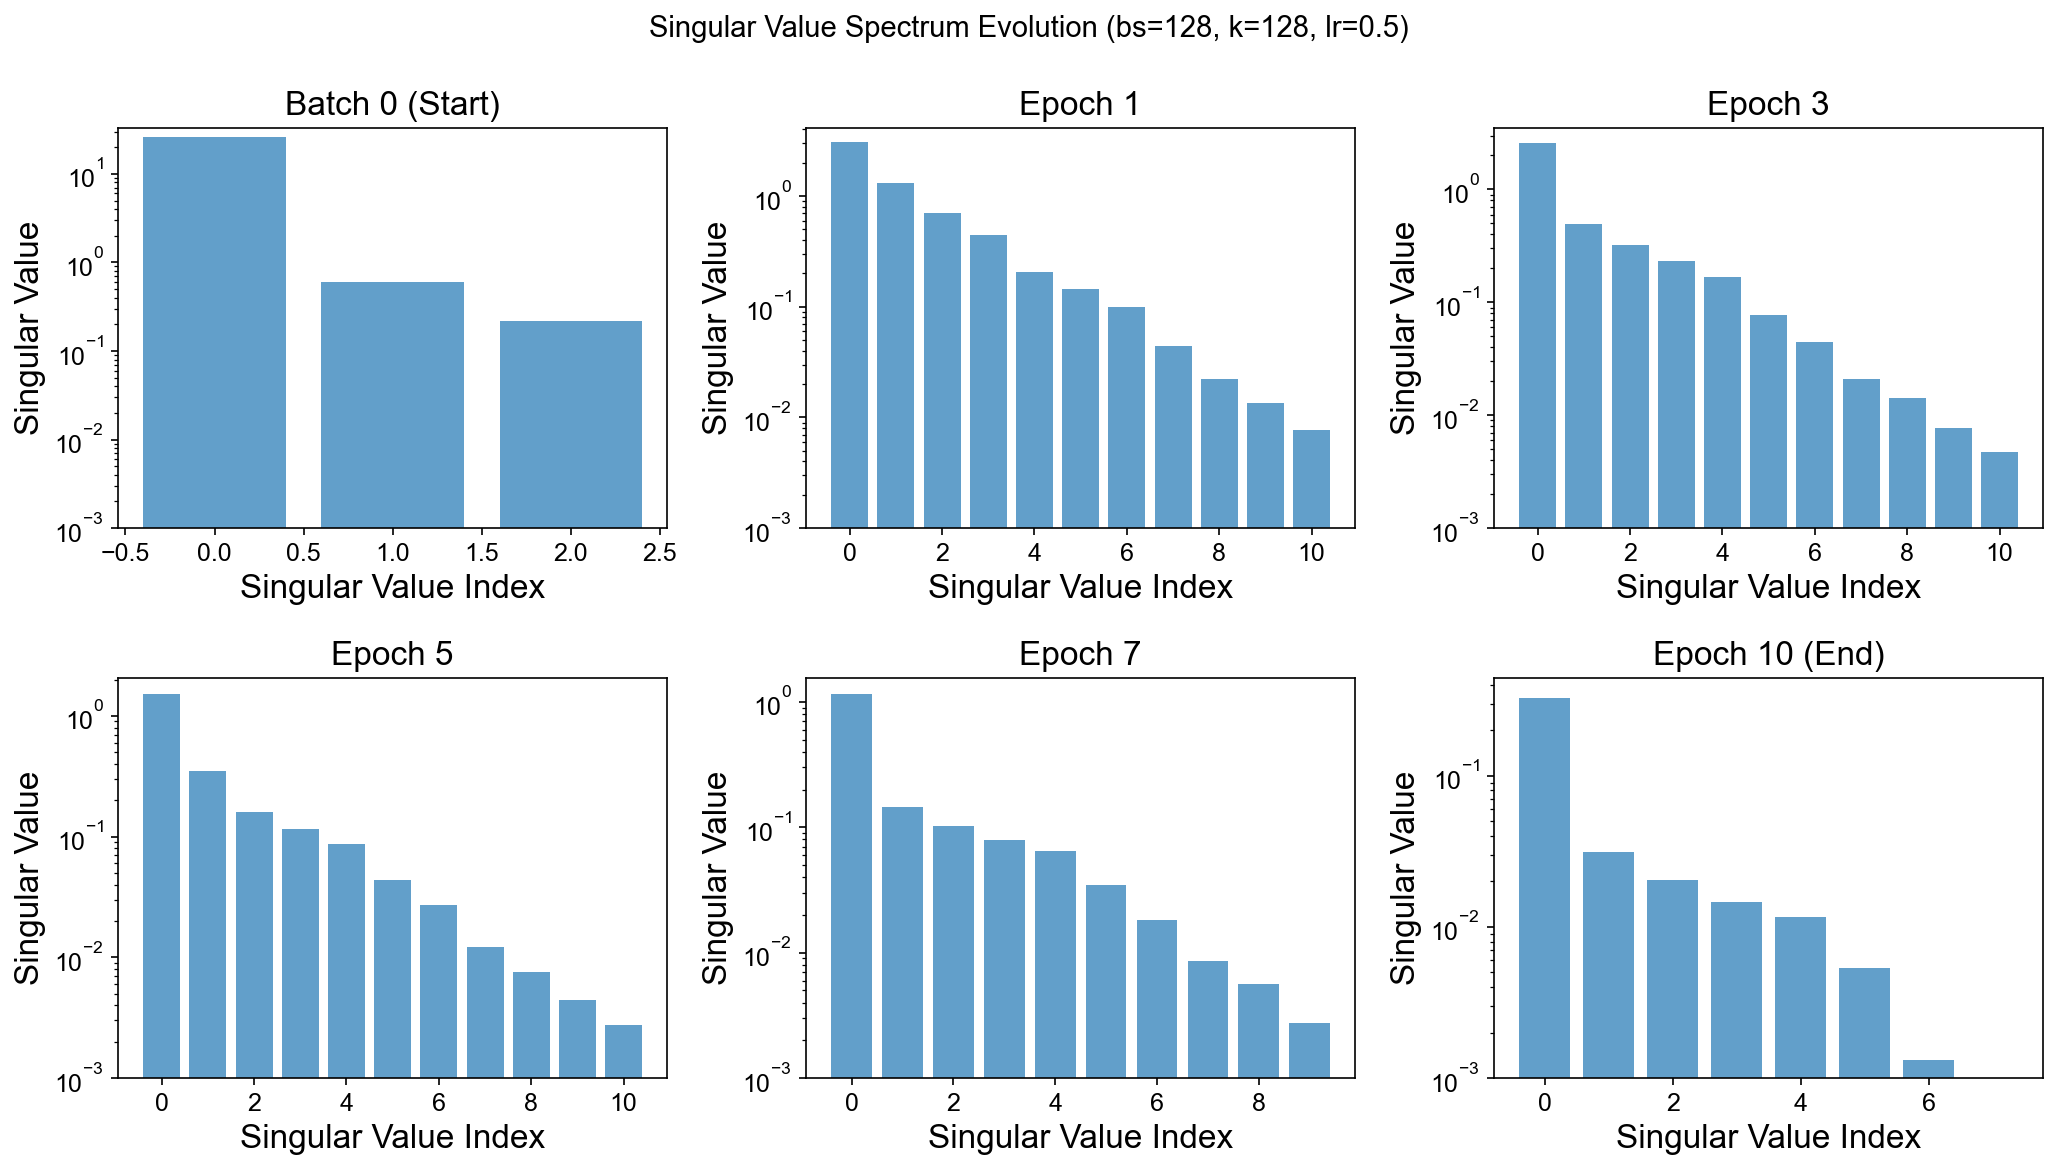

In [ ]:
# Plot singular value spectrum at different points during training
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# Select a configuration
cfg = {'batch_size': 128, 'k_fraction': 1.0, 'lr': 0.5}
row = df_svd[(df_svd['batch_size'] == cfg['batch_size']) & 
              (df_svd['k_fraction'] == cfg['k_fraction']) & 
              (df_svd['lr'] == cfg['lr'])].iloc[0]

svs_list, _ = get_svd_info(row)

if svs_list is not None:
    total_batches = len(svs_list)
    batches_per_epoch = total_batches // 10
    
    # Sample at start, middle epochs, and end
    sample_points = [
        (0, 'Batch 0 (Start)'),
        (batches_per_epoch, f'Epoch 1'),
        (3 * batches_per_epoch, f'Epoch 3'),
        (5 * batches_per_epoch, f'Epoch 5'),
        (7 * batches_per_epoch, f'Epoch 7'),
        (total_batches - 1, f'Epoch 10 (End)'),
    ]
    
    for ax, (batch_idx, title) in zip(axes.flat, sample_points):
        svs = svs_list[batch_idx]
        ax.bar(range(len(svs)), sorted(svs, reverse=True), color='C0', alpha=0.7)
        ax.set_xlabel('Singular Value Index')
        ax.set_ylabel('Singular Value')
        ax.set_title(title)
        ax.set_yscale('log')
        ax.set_ylim(1e-3, None)

plt.suptitle(f"Singular Value Spectrum Evolution (bs={cfg['batch_size']}, k={int(row['k'])}, lr={cfg['lr']})", 
             fontsize=14)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'sv_spectrum_evolution.pdf')
#plt.savefig(PLOT_DIR / 'sv_spectrum_evolution.png')
plt.show()

### 4.3 Singular Value Statistics Over Training

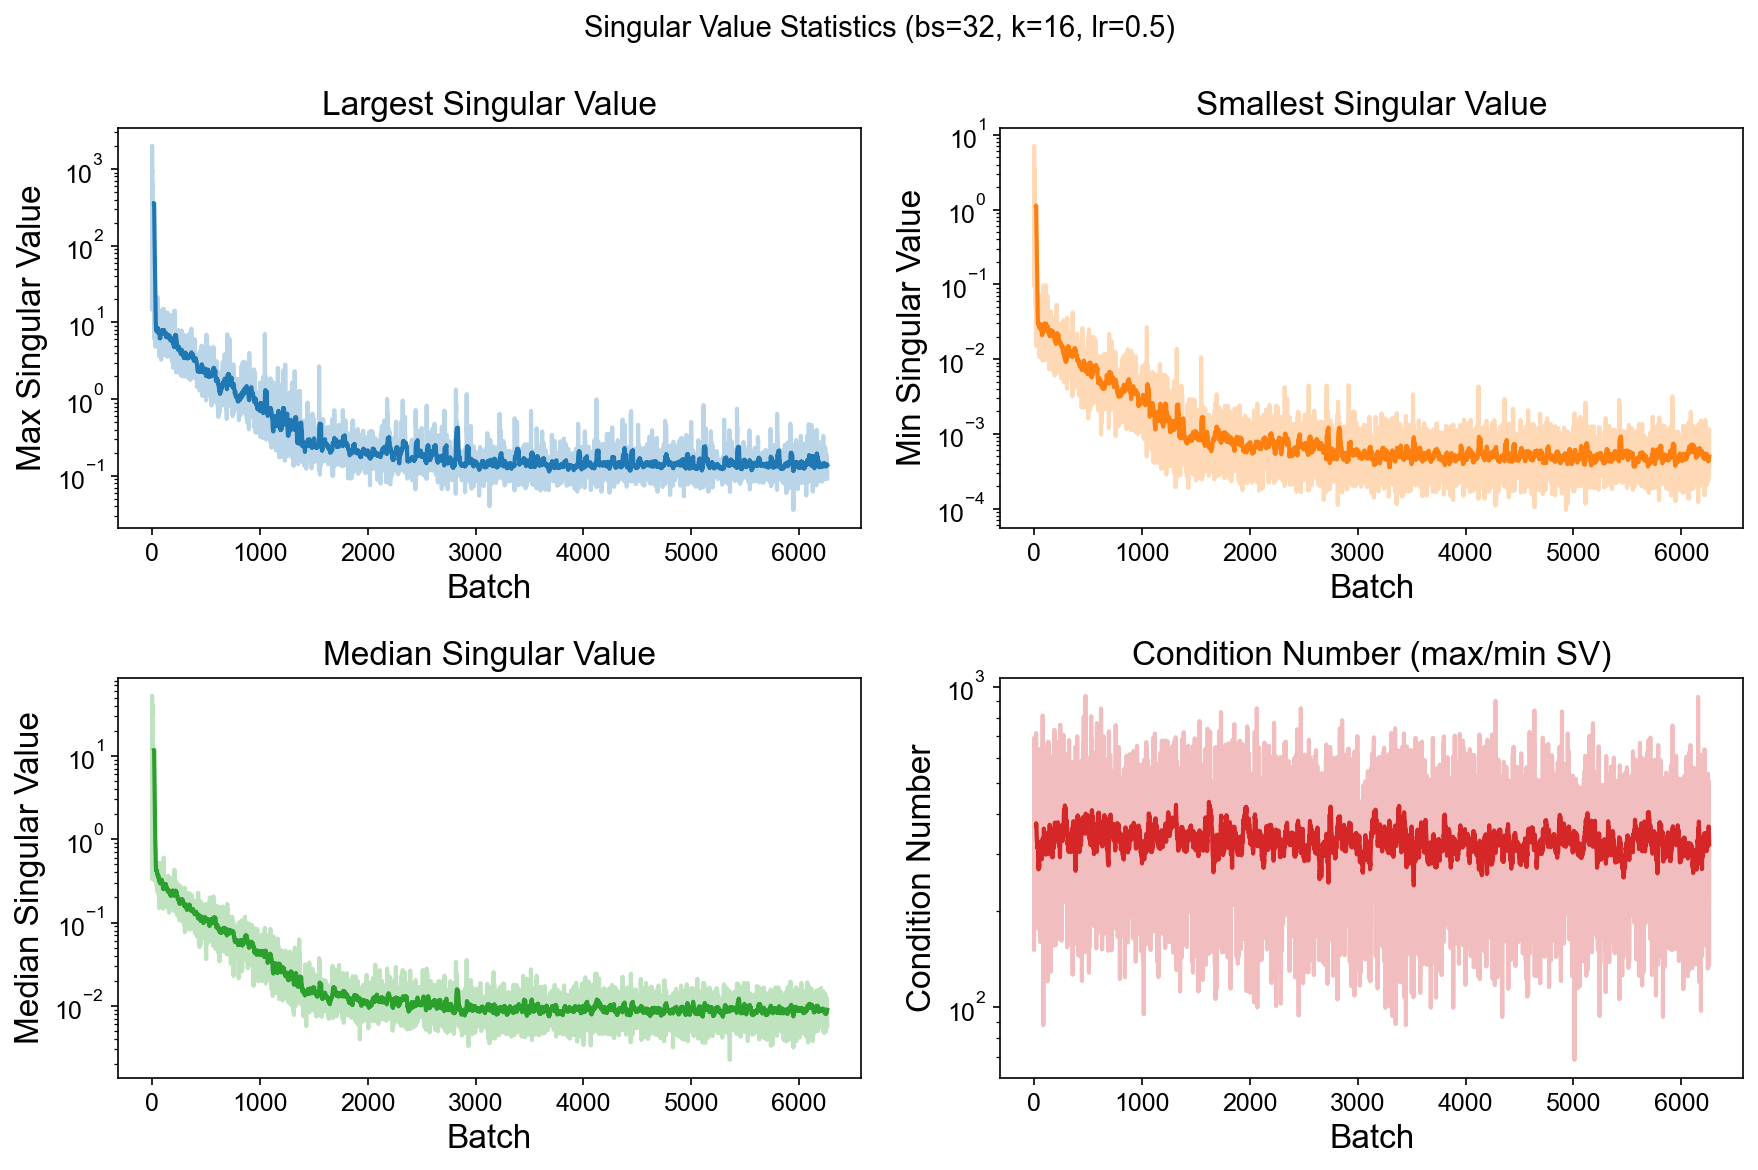

In [103]:
# Track SV statistics (max, median, min, condition number) over training
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

cfg = {'batch_size': 32, 'k_fraction': 0.5, 'lr': 0.5}
row = df_svd[(df_svd['batch_size'] == cfg['batch_size']) & 
              (df_svd['k_fraction'] == cfg['k_fraction']) & 
              (df_svd['lr'] == cfg['lr'])].iloc[0]

svs_list, _ = get_svd_info(row)

if svs_list is not None:
    max_svs = [np.max(svs) if len(svs) > 0 else np.nan for svs in svs_list]
    min_svs = [np.min(svs) if len(svs) > 0 else np.nan for svs in svs_list]
    median_svs = [np.median(svs) if len(svs) > 0 else np.nan for svs in svs_list]
    condition = [np.max(svs)/np.min(svs) if len(svs) > 0 and np.min(svs) > 0 else np.nan 
                 for svs in svs_list]
    
    batches = np.arange(len(svs_list))
    window = 20
    
    # Max SV
    ax = axes[0, 0]
    ax.plot(batches, max_svs, alpha=0.3, color='C0')
    ax.plot(batches[window-1:], sliding_average(max_svs, window), 'C0', linewidth=2)
    ax.set_xlabel('Batch')
    ax.set_ylabel('Max Singular Value')
    ax.set_title('Largest Singular Value')
    ax.set_yscale('log')
    
    # Min SV
    ax = axes[0, 1]
    ax.plot(batches, min_svs, alpha=0.3, color='C1')
    ax.plot(batches[window-1:], sliding_average(min_svs, window), 'C1', linewidth=2)
    ax.set_xlabel('Batch')
    ax.set_ylabel('Min Singular Value')
    ax.set_title('Smallest Singular Value')
    ax.set_yscale('log')
    
    # Median SV
    ax = axes[1, 0]
    ax.plot(batches, median_svs, alpha=0.3, color='C2')
    ax.plot(batches[window-1:], sliding_average(median_svs, window), 'C2', linewidth=2)
    ax.set_xlabel('Batch')
    ax.set_ylabel('Median Singular Value')
    ax.set_title('Median Singular Value')
    ax.set_yscale('log')
    
    # Condition number
    ax = axes[1, 1]
    ax.plot(batches, condition, alpha=0.3, color='C3')
    valid_condition = [c for c in condition if not np.isnan(c)]
    if len(valid_condition) > window:
        ax.plot(batches[window-1:len(valid_condition)+window-1], 
                sliding_average(valid_condition[:len(valid_condition)], window), 'C3', linewidth=2)
    ax.set_xlabel('Batch')
    ax.set_ylabel('Condition Number')
    ax.set_title('Condition Number (max/min SV)')
    ax.set_yscale('log')

plt.suptitle(f"Singular Value Statistics (bs={cfg['batch_size']}, k={int(row['k'])}, lr={cfg['lr']})", 
             fontsize=14)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'sv_statistics.pdf')
plt.savefig(PLOT_DIR / 'sv_statistics.png')
plt.show()

### 4.4 Effective Rank vs Batch Size Comparison

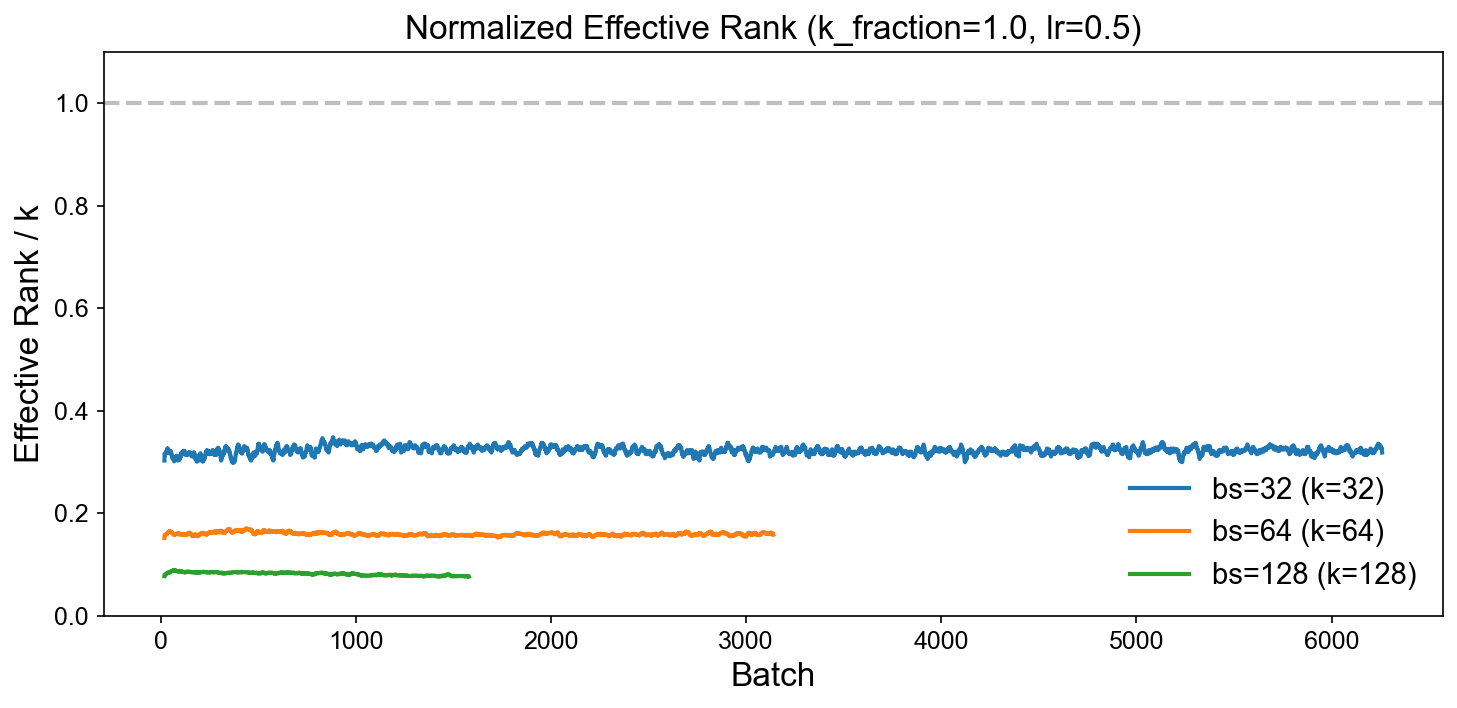

In [104]:
# Compare effective rank across batch sizes (all with k_fraction=1.0)
fig, ax = plt.subplots(figsize=(10, 5))

fixed_lr = 0.5
fixed_kf = 1.0

for i, bs in enumerate(batch_sizes):
    data = df_svd[(df_svd['batch_size'] == bs) & 
                   (df_svd['k_fraction'] == fixed_kf) & 
                   (df_svd['lr'] == fixed_lr)]
    if len(data) > 0:
        row = data.iloc[0]
        _, num_nonzero = get_svd_info(row)
        if num_nonzero is not None:
            batches = np.arange(len(num_nonzero))
            window = 20
            smoothed = sliding_average(num_nonzero, window)
            # Normalize by max k for comparison
            ax.plot(batches[window-1:], smoothed / row['k'], 
                   label=f'bs={bs} (k={int(row["k"])})', color=f'C{i}')

ax.set_xlabel('Batch')
ax.set_ylabel('Effective Rank / k')
ax.set_title(f'Normalized Effective Rank (k_fraction={fixed_kf}, lr={fixed_lr})')
ax.legend()
ax.set_ylim(0, 1.1)
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(PLOT_DIR / 'effective_rank_comparison.pdf')
plt.savefig(PLOT_DIR / 'effective_rank_comparison.png')
plt.show()

### 4.5 Correlation: Effective Rank vs Loss

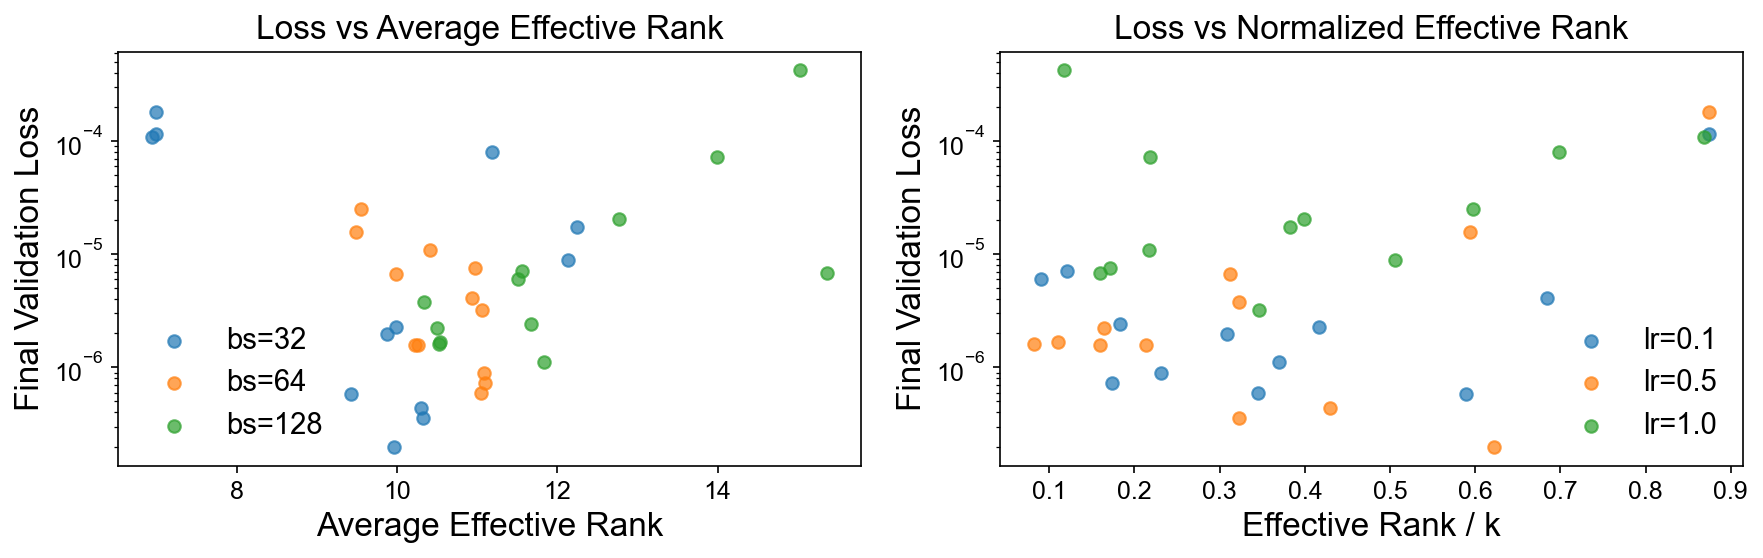

In [105]:
# Plot loss vs effective rank (averaged over training)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Compute average effective rank for each SVD run
avg_ranks = []
for idx, row in df_svd.iterrows():
    _, num_nonzero = get_svd_info(row)
    if num_nonzero is not None:
        avg_ranks.append({
            'batch_size': row['batch_size'],
            'k': row['k'],
            'k_fraction': row['k_fraction'],
            'lr': row['lr'],
            'final_val_loss': row['final_val_loss'],
            'avg_eff_rank': np.mean(num_nonzero),
            'final_eff_rank': np.mean(num_nonzero[-100:]),  # Last 100 batches
            'eff_rank_ratio': np.mean(num_nonzero) / row['k']
        })

rank_df = pd.DataFrame(avg_ranks)

# Plot: effective rank vs loss
ax = axes[0]
for bs in batch_sizes:
    bs_data = rank_df[rank_df['batch_size'] == bs]
    ax.scatter(bs_data['avg_eff_rank'], bs_data['final_val_loss'], 
               label=f'bs={bs}', alpha=0.7)

ax.set_xlabel('Average Effective Rank')
ax.set_ylabel('Final Validation Loss')
ax.set_title('Loss vs Average Effective Rank')
ax.set_yscale('log')
ax.legend()

# Plot: effective rank ratio vs loss
ax = axes[1]
for lr in svd_lrs:
    lr_data = rank_df[rank_df['lr'] == lr]
    ax.scatter(lr_data['eff_rank_ratio'], lr_data['final_val_loss'], 
               label=f'lr={lr}', alpha=0.7)

ax.set_xlabel('Effective Rank / k')
ax.set_ylabel('Final Validation Loss')
ax.set_title('Loss vs Normalized Effective Rank')
ax.set_yscale('log')
ax.legend()

plt.tight_layout()
plt.savefig(PLOT_DIR / 'effective_rank_vs_loss.pdf')
plt.savefig(PLOT_DIR / 'effective_rank_vs_loss.png')
plt.show()

## 5. Summary and Interpretation

### Key Findings

#### Optimizer Comparison
- SVD optimizer can achieve competitive or better final validation loss compared to Adam/SGD/RMSprop
- The learning rate regime is different: SVD works well with larger learning rates (0.1-1.0) while standard optimizers need smaller rates (1e-4 to 1e-2)

#### Hyperparameter Selection Guidelines

**Learning Rate:**
- Optimal SVD learning rate is typically 0.1-0.5
- Higher learning rates (1.0) can work but may be less stable
- The pseudo-inverse naturally controls the step size, allowing larger nominal learning rates

**Batch Size:**
- Larger batch sizes provide more information per step but increase computational cost
- Performance generally improves with batch size up to a point
- The Jacobian matrix size scales with batch size, affecting memory

**Number of Singular Values (k):**
- k_fraction of 0.5-1.0 typically works well
- Too small k can lose important gradient information
- The actual effective rank (nonzero SVs after truncation by rtol) is often smaller than k
- This suggests the loss landscape has inherently lower effective dimension

#### Singular Value Insights

1. **Effective Rank < k**: The actual number of significant singular values is typically much smaller than the maximum k, suggesting the per-sample loss landscape has low intrinsic dimensionality.

2. **Spectrum Evolution**: The singular value spectrum changes during training:
   - Early: More spread out spectrum
   - Late: Potentially more concentrated as the model converges

3. **Condition Number**: The ratio of largest to smallest singular value indicates the conditioning of the optimization problem. High condition numbers may suggest ill-conditioned regions.

4. **Interpretation**: The singular values of the Jacobian M represent the sensitivities of individual loss components to parameter changes. Large SVs correspond to directions where small parameter changes cause large loss changes.

In [18]:
# Summary statistics table
print("=" * 60)
print("SUMMARY STATISTICS")
print("=" * 60)

print("\nBest performance by optimizer:")
print(best_df.to_string(index=False))

print("\n" + "-" * 60)
print("\nSVD optimizer statistics:")
print(f"  Final validation loss: min={df_svd['final_val_loss'].min():.2e}, "
      f"median={df_svd['final_val_loss'].median():.2e}, "
      f"max={df_svd['final_val_loss'].max():.2e}")

print("\nBaseline optimizer statistics:")
for opt in baseline_optimizers:
    opt_data = df_baseline[df_baseline['optimizer'] == opt]
    print(f"  {opt}: min={opt_data['final_val_loss'].min():.2e}, "
          f"median={opt_data['final_val_loss'].median():.2e}, "
          f"max={opt_data['final_val_loss'].max():.2e}")

SUMMARY STATISTICS

Best performance by optimizer:
optimizer  final_val_loss    lr  batch_size    k  k_fraction
      SVD    7.229901e-08 1.000          32 32.0         1.0
     Adam    9.998476e-06 0.010          64  NaN         NaN
    AdamW    4.041740e-05 0.001          64  NaN         NaN
      SGD    3.239005e-04 0.100          32  NaN         NaN
  RMSprop    2.175041e-04 0.001          64  NaN         NaN

------------------------------------------------------------

SVD optimizer statistics:
  Final validation loss: min=7.23e-08, median=4.96e-05, max=9.68e-01

Baseline optimizer statistics:
  Adam: min=1.00e-05, median=2.49e-03, max=9.79e-01
  AdamW: min=4.04e-05, median=1.57e-03, max=9.79e-01
  SGD: min=3.24e-04, median=9.60e-01, max=1.05e+00
  RMSprop: min=2.18e-04, median=1.68e-01, max=2.12e+00


In [38]:
print(f"\nAll plots saved to: {PLOT_DIR.absolute()}")
print("\nGenerated files:")
for f in sorted(PLOT_DIR.glob('*')):
    print(f"  {f.name}")


All plots saved to: /Users/sambt/iaifi/sv3/claude_experiments/plots/toy_1d

Generated files:
  batch_size_effect.pdf
  batch_size_effect_lr0.01_kf0.1.pdf
  batch_size_effect_lr0.01_kf0.25.pdf
  batch_size_effect_lr0.01_kf0.5.pdf
  batch_size_effect_lr0.01_kf0.75.pdf
  batch_size_effect_lr0.01_kf1.0.pdf
  batch_size_effect_lr0.1_kf0.1.pdf
  batch_size_effect_lr0.1_kf0.25.pdf
  batch_size_effect_lr0.1_kf0.5.pdf
  batch_size_effect_lr0.1_kf0.75.pdf
  batch_size_effect_lr0.1_kf1.0.pdf
  batch_size_effect_lr0.5_kf0.1.pdf
  batch_size_effect_lr0.5_kf0.25.pdf
  batch_size_effect_lr0.5_kf0.5.pdf
  batch_size_effect_lr0.5_kf0.75.pdf
  batch_size_effect_lr0.5_kf1.0.pdf
  batch_size_effect_lr1.0_kf0.1.pdf
  batch_size_effect_lr1.0_kf0.25.pdf
  batch_size_effect_lr1.0_kf0.5.pdf
  batch_size_effect_lr1.0_kf0.75.pdf
  batch_size_effect_lr1.0_kf1.0.pdf
  best_loss_vs_batchsize.pdf
  best_optimizer_comparison.pdf
  best_optimizer_comparison.png
  best_train_val_loss_bs128.pdf
  best_train_val_loss_bs